<a href="https://colab.research.google.com/github/romenmeitei/Computational-analysis-of-SMA/blob/main/Distance_correlation_ligand_RNA_binding_residues.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install MDAnalysis pandas scipy matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.9/108.9 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 78.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 104.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 3.9 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, mannwhitneyu
import MDAnalysis as mda
from MDAnalysis.analysis import distances

xtc_file = "/content/md_200ns.xtc"
tpr_file = "/content/md_200ns.tpr"

u = mda.Universe(tpr_file, xtc_file)
print(u)
print("Frames:", len(u.trajectory))

<Universe with 61660 atoms>
Frames: 2001


In [3]:
res_df = pd.DataFrame(
    [(res.resname, res.resid, len(res.atoms), res.segid) for res in u.residues],
    columns=["resname", "resid", "n_atoms", "segid"]
)

summary = (
    res_df.groupby("resname")
    .agg(n_residues=("resid", "count"),
         min_resid=("resid", "min"),
         max_resid=("resid", "max"),
         mean_atoms=("n_atoms", "mean"))
    .reset_index()
    .sort_values(["n_residues", "mean_atoms"], ascending=[False, False])
)

display(summary)

,resname,n_residues,min_resid,max_resid,mean_atoms
22,TIP3,19405,316,19720,3.000000
18,POT,66,195,260,1.000000
5,CLA,55,261,315,1.000000
27,VAL,17,38,171,16.000000
9,GLU,17,3,179,15.000000
15,LYS,15,2,177,22.000000
2,ARG,14,8,172,24.000000
10,GLY,14,13,166,7.000000
4,ASP,13,21,154,12.000000
21,THR,12,19,163,14.000000


In [4]:
# >>> CHANGE THIS after inspecting Cell 3 output <<<
LIGAND_RESNAME = "UNK"   # example only

# Ligand
ligand = u.select_atoms(f"resname {LIGAND_RESNAME}")

# Ligand-contact hotspot from your manuscript
hotspot = u.select_atoms("protein and resid 85 86")

# RNA
rna = u.select_atoms("nucleic")

# Define RNA-binding site automatically from frame 0:
# all protein atoms within 4.5 Å of RNA in the starting structure
u.trajectory[0]
rna_binding_site = u.select_atoms("protein and around 4.5 nucleic")

print("Ligand atoms:", len(ligand))
print("Hotspot atoms:", len(hotspot))
print("RNA atoms:", len(rna))
print("RNA-binding-site atoms:", len(rna_binding_site))

if len(ligand) == 0:
    raise ValueError("Ligand selection is empty. Update LIGAND_RESNAME.")
if len(hotspot) == 0:
    raise ValueError("Hotspot selection is empty.")
if len(rna) == 0:
    raise ValueError("RNA selection is empty.")
if len(rna_binding_site) == 0:
    raise ValueError("RNA-binding-site selection is empty.")

Ligand atoms: 72
Hotspot atoms: 35
RNA atoms: 354
RNA-binding-site atoms: 212


In [5]:
rna_site_residues = sorted(set((a.resid, a.resname) for a in rna_binding_site.residues.atoms))
rna_site_df = pd.DataFrame(rna_site_residues, columns=["resid", "resname"])
display(rna_site_df)

,resid,resname
0,6,GLN
1,9,LYS
2,11,PHE
3,13,GLY
4,14,GLY
5,15,LEU
6,17,PHE
7,40,MET
8,43,PRO
9,49,ARG


In [6]:
rows = []

for ts in u.trajectory:
    time_ps = ts.time
    frame = ts.frame

    # Centers of mass
    lig_com = ligand.center_of_mass()
    hotspot_com = hotspot.center_of_mass()
    rna_com = rna.center_of_mass()
    rna_site_com = rna_binding_site.center_of_mass()

    # Distance 1: ligand to hotspot
    lig_hotspot_dist = np.linalg.norm(lig_com - hotspot_com)

    # Distance 2: RNA to RNA-binding site
    rna_site_dist = np.linalg.norm(rna_com - rna_site_com)

    # Protein-RNA atomic contact count (RNA-binding site vs RNA)
    dmat_pr = distances.distance_array(rna_binding_site.positions, rna.positions)
    protein_rna_contacts = int(np.sum(dmat_pr < 4.5))

    # Ligand-hotspot contact count
    dmat_lh = distances.distance_array(ligand.positions, hotspot.positions)
    ligand_hotspot_contacts = int(np.sum(dmat_lh < 4.5))

    rows.append({
        "frame": frame,
        "time_ps": time_ps,
        "time_ns": time_ps / 1000.0,
        "lig_hotspot_dist": lig_hotspot_dist,
        "rna_site_dist": rna_site_dist,
        "protein_rna_contacts": protein_rna_contacts,
        "ligand_hotspot_contacts": ligand_hotspot_contacts
    })

df = pd.DataFrame(rows)
df.to_csv("/content/ligand_rna_dynamic_coupling.csv", index=False)
display(df.head())
print("Saved: /content/ligand_rna_dynamic_coupling.csv")

,frame,time_ps,time_ns,lig_hotspot_dist,rna_site_dist,protein_rna_contacts,ligand_hotspot_contacts
0,0,0.0,0.0,13.190511,7.902825,1316,0
1,1,100.0,0.1,12.686525,7.962521,1258,0
2,2,200.0,0.2,13.455565,7.816398,1192,0
3,3,300.0,0.3,13.416593,8.788293,1261,0
4,4,400.0,0.4,13.327238,8.726533,1297,0


Saved: /content/ligand_rna_dynamic_coupling.csv


In [7]:
rho1, p1 = spearmanr(df["lig_hotspot_dist"], df["protein_rna_contacts"])
rho2, p2 = spearmanr(df["lig_hotspot_dist"], df["rna_site_dist"])
rho3, p3 = spearmanr(df["ligand_hotspot_contacts"], df["protein_rna_contacts"])

corr_df = pd.DataFrame([
    ["Ligand–hotspot distance vs protein–RNA contacts", rho1, p1],
    ["Ligand–hotspot distance vs RNA-site distance", rho2, p2],
    ["Ligand–hotspot contacts vs protein–RNA contacts", rho3, p3],
], columns=["comparison", "spearman_rho", "p_value"])

corr_df.to_csv("/content/correlation_results.csv", index=False)
display(corr_df)
print("Saved: /content/correlation_results.csv")

,comparison,spearman_rho,p_value
0,Ligand–hotspot distance vs protein–RNA contacts,-0.099054,9.033895e-06
1,Ligand–hotspot distance vs RNA-site distance,0.124521,2.291647e-08
2,Ligand–hotspot contacts vs protein–RNA contacts,0.127971,9.219062e-09


Saved: /content/correlation_results.csv


In [8]:
threshold = df["lig_hotspot_dist"].median()

close_df = df[df["lig_hotspot_dist"] <= threshold].copy()
far_df   = df[df["lig_hotspot_dist"] > threshold].copy()

u_stat1, p_mw1 = mannwhitneyu(close_df["protein_rna_contacts"],
                              far_df["protein_rna_contacts"],
                              alternative="two-sided")

u_stat2, p_mw2 = mannwhitneyu(close_df["rna_site_dist"],
                              far_df["rna_site_dist"],
                              alternative="two-sided")

state_stats = pd.DataFrame([
    ["Protein–RNA contacts", close_df["protein_rna_contacts"].mean(), far_df["protein_rna_contacts"].mean(), p_mw1],
    ["RNA-site COM distance", close_df["rna_site_dist"].mean(), far_df["rna_site_dist"].mean(), p_mw2],
], columns=["metric", "mean_close", "mean_far", "p_mannwhitney"])

state_stats.to_csv("/content/close_vs_far_state_stats.csv", index=False)

print("Median ligand–hotspot distance threshold:", threshold)
display(state_stats)
print("Saved: /content/close_vs_far_state_stats.csv")

Median ligand–hotspot distance threshold: 18.54310247612995


,metric,mean_close,mean_far,p_mannwhitney
0,Protein–RNA contacts,993.603397,973.999000,0.000095
1,RNA-site COM distance,11.989673,12.291754,0.000063


Saved: /content/close_vs_far_state_stats.csv


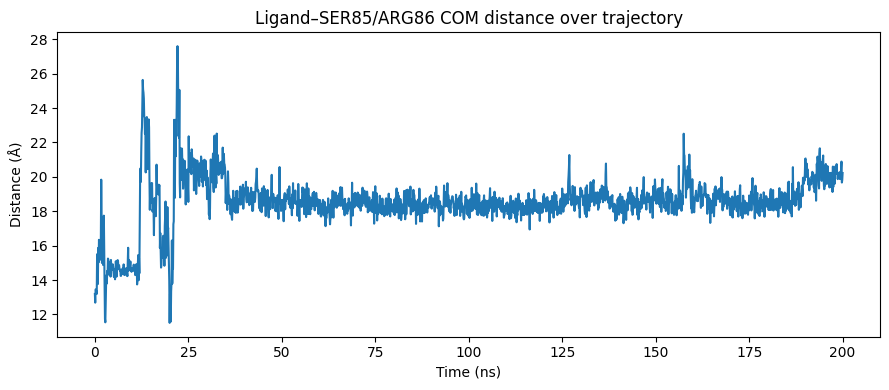

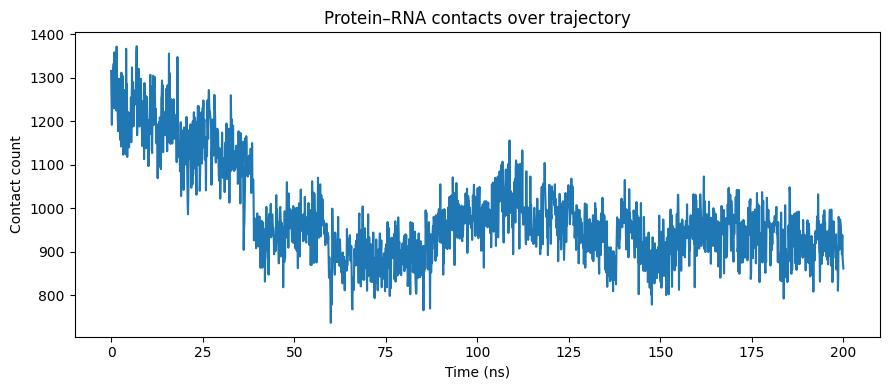

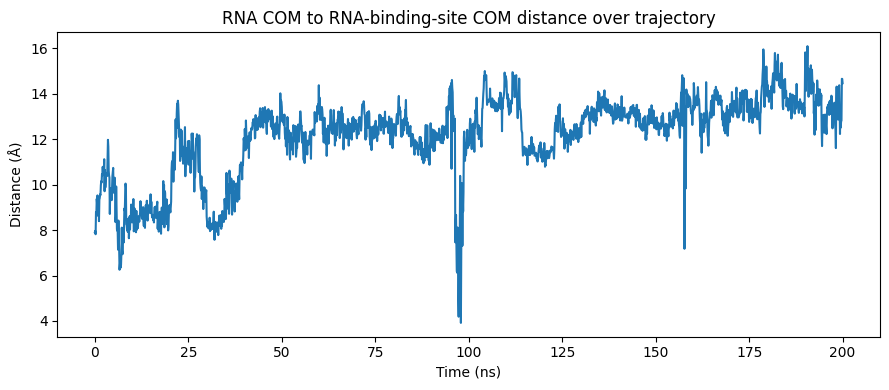

In [9]:
plt.figure(figsize=(9,4))
plt.plot(df["time_ns"], df["lig_hotspot_dist"])
plt.xlabel("Time (ns)")
plt.ylabel("Distance (Å)")
plt.title("Ligand–SER85/ARG86 COM distance over trajectory")
plt.tight_layout()
plt.savefig("/content/ligand_hotspot_distance_timeseries.png", dpi=300)
plt.show()

plt.figure(figsize=(9,4))
plt.plot(df["time_ns"], df["protein_rna_contacts"])
plt.xlabel("Time (ns)")
plt.ylabel("Contact count")
plt.title("Protein–RNA contacts over trajectory")
plt.tight_layout()
plt.savefig("/content/protein_rna_contacts_timeseries.png", dpi=300)
plt.show()

plt.figure(figsize=(9,4))
plt.plot(df["time_ns"], df["rna_site_dist"])
plt.xlabel("Time (ns)")
plt.ylabel("Distance (Å)")
plt.title("RNA COM to RNA-binding-site COM distance over trajectory")
plt.tight_layout()
plt.savefig("/content/rna_site_distance_timeseries.png", dpi=300)
plt.show()

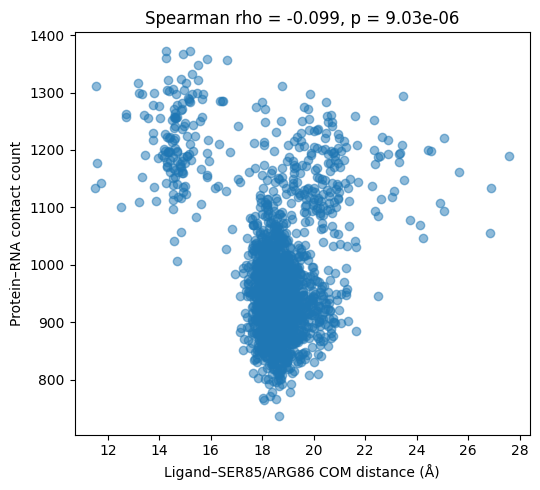

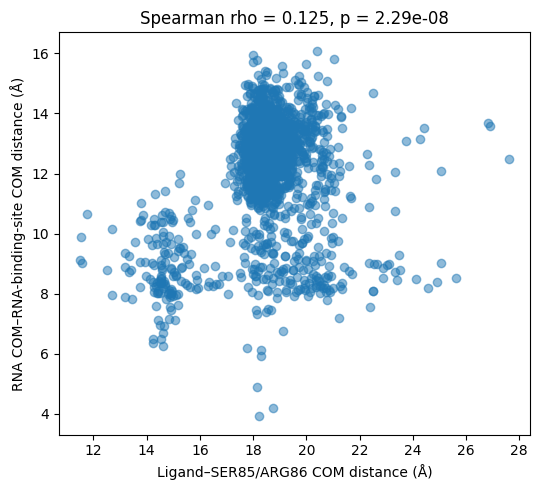

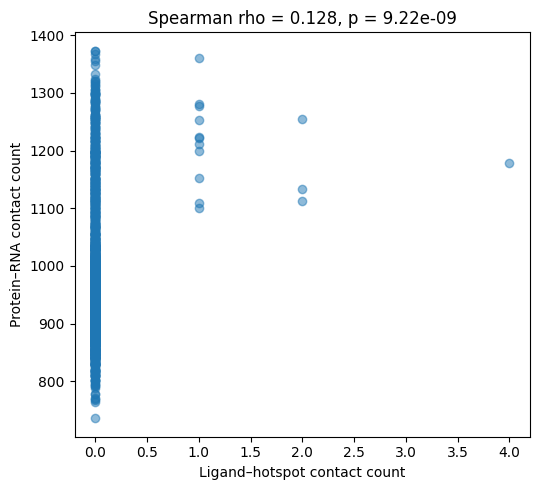

In [10]:
plt.figure(figsize=(5.5,5))
plt.scatter(df["lig_hotspot_dist"], df["protein_rna_contacts"], alpha=0.5)
plt.xlabel("Ligand–SER85/ARG86 COM distance (Å)")
plt.ylabel("Protein–RNA contact count")
plt.title(f"Spearman rho = {rho1:.3f}, p = {p1:.3g}")
plt.tight_layout()
plt.savefig("/content/scatter_ligdist_vs_prcontacts.png", dpi=300)
plt.show()

plt.figure(figsize=(5.5,5))
plt.scatter(df["lig_hotspot_dist"], df["rna_site_dist"], alpha=0.5)
plt.xlabel("Ligand–SER85/ARG86 COM distance (Å)")
plt.ylabel("RNA COM–RNA-binding-site COM distance (Å)")
plt.title(f"Spearman rho = {rho2:.3f}, p = {p2:.3g}")
plt.tight_layout()
plt.savefig("/content/scatter_ligdist_vs_rnasitedist.png", dpi=300)
plt.show()

plt.figure(figsize=(5.5,5))
plt.scatter(df["ligand_hotspot_contacts"], df["protein_rna_contacts"], alpha=0.5)
plt.xlabel("Ligand–hotspot contact count")
plt.ylabel("Protein–RNA contact count")
plt.title(f"Spearman rho = {rho3:.3f}, p = {p3:.3g}")
plt.tight_layout()
plt.savefig("/content/scatter_ligcontacts_vs_prcontacts.png", dpi=300)
plt.show()

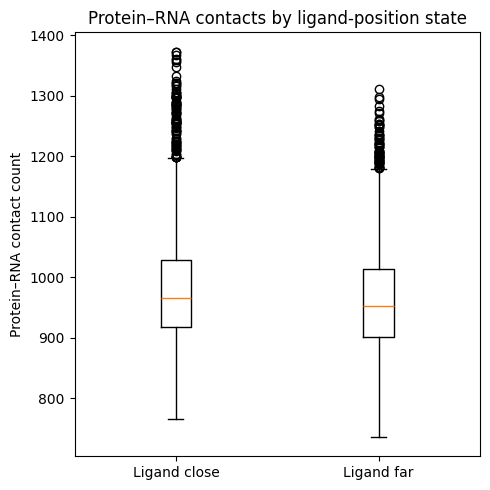

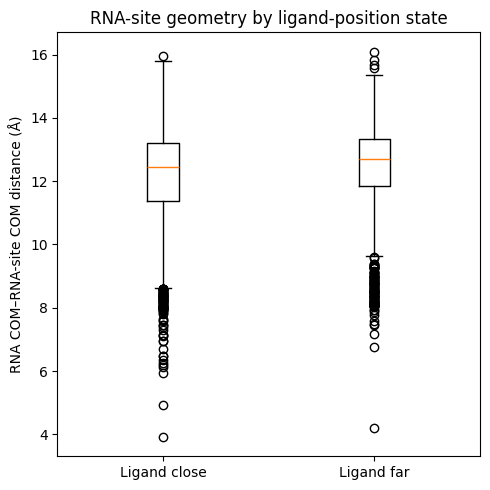

In [11]:
plt.figure(figsize=(5,5))
plt.boxplot(
    [close_df["protein_rna_contacts"], far_df["protein_rna_contacts"]],
    tick_labels=["Ligand close", "Ligand far"]
)
plt.ylabel("Protein–RNA contact count")
plt.title("Protein–RNA contacts by ligand-position state")
plt.tight_layout()
plt.savefig("/content/boxplot_close_far_protein_rna_contacts.png", dpi=300)
plt.show()

plt.figure(figsize=(5,5))
plt.boxplot(
    [close_df["rna_site_dist"], far_df["rna_site_dist"]],
    tick_labels=["Ligand close", "Ligand far"]
)
plt.ylabel("RNA COM–RNA-site COM distance (Å)")
plt.title("RNA-site geometry by ligand-position state")
plt.tight_layout()
plt.savefig("/content/boxplot_close_far_rna_site_dist.png", dpi=300)
plt.show()

In [12]:
summary_text = f"""
Dynamic coupling analysis summary

Ligand residue name: {LIGAND_RESNAME}
Frames analyzed: {len(df)}
Median ligand–hotspot distance threshold: {threshold:.3f} Å

Spearman correlations:
1. Ligand–hotspot distance vs protein–RNA contacts:
   rho = {rho1:.4f}, p = {p1:.4g}

2. Ligand–hotspot distance vs RNA-site COM distance:
   rho = {rho2:.4f}, p = {p2:.4g}

3. Ligand–hotspot contacts vs protein–RNA contacts:
   rho = {rho3:.4f}, p = {p3:.4g}

State comparison:
Protein–RNA contacts:
   mean_close = {close_df["protein_rna_contacts"].mean():.3f}
   mean_far   = {far_df["protein_rna_contacts"].mean():.3f}
   p_mannwhitney = {p_mw1:.4g}

RNA-site COM distance:
   mean_close = {close_df["rna_site_dist"].mean():.3f}
   mean_far   = {far_df["rna_site_dist"].mean():.3f}
   p_mannwhitney = {p_mw2:.4g}
"""

print(summary_text)

with open("/content/dynamic_coupling_summary.txt", "w") as f:
    f.write(summary_text)

print("Saved: /content/dynamic_coupling_summary.txt")


Dynamic coupling analysis summary

Ligand residue name: UNK
Frames analyzed: 2001
Median ligand–hotspot distance threshold: 18.543 Å

Spearman correlations:
1. Ligand–hotspot distance vs protein–RNA contacts:
   rho = -0.0991, p = 9.034e-06

2. Ligand–hotspot distance vs RNA-site COM distance:
   rho = 0.1245, p = 2.292e-08

3. Ligand–hotspot contacts vs protein–RNA contacts:
   rho = 0.1280, p = 9.219e-09

State comparison:
Protein–RNA contacts:
   mean_close = 993.603
   mean_far   = 973.999
   p_mannwhitney = 9.479e-05

RNA-site COM distance:
   mean_close = 11.990
   mean_far   = 12.292
   p_mannwhitney = 6.347e-05

Saved: /content/dynamic_coupling_summary.txt
